<a href="https://colab.research.google.com/github/r-pranav-git/Deep-Learning-Workshop/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
CNN Image Classification using TensorFlow/Keras

Programs:
1. Fashion-MNIST Classification
2. Intel Image Classification

Deep Learning Workshop
TKM College of Engineering
"""

CNN Program 1

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(X_train,y_train),(X_test,y_test)=datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
class_names=[
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

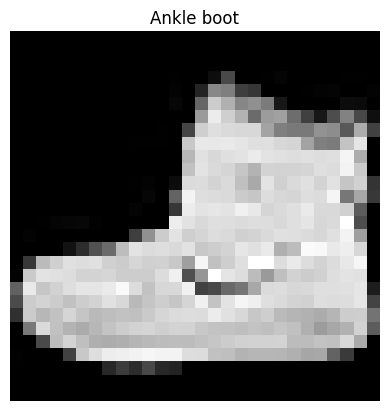

In [ ]:
plt.imshow(X_train[0],cmap='gray')
plt.title(class_names[y_train[0]])
plt.axis('off')
plt.show()

In [ ]:
#Normalization-for effective working of model
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
print(X_train.shape)

(60000, 28, 28)


In [ ]:
X_train=X_train.reshape(60000,28,28,1)
X_test=X_test.reshape(10000,28,28,1)
print(X_train.shape)

(60000, 28, 28, 1)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8247 - loss: 0.4877 - val_accuracy: 0.8673 - val_loss: 0.3585
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8803 - loss: 0.3284 - val_accuracy: 0.8907 - val_loss: 0.3049
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8940 - loss: 0.2845 - val_accuracy: 0.8876 - val_loss: 0.3099
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9079 - loss: 0.2526 - val_accuracy: 0.9007 - val_loss: 0.2729
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9144 - loss: 0.2306 - val_accuracy: 0.9084 - val_loss: 0.2534
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9229 - loss: 0.2070 - val_accuracy: 0.9080 - val_loss: 0.2595
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9275 - loss: 0.1897 - val_accuracy: 0.9094 - val_loss: 0.2534
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9338 - loss: 0.1734 -

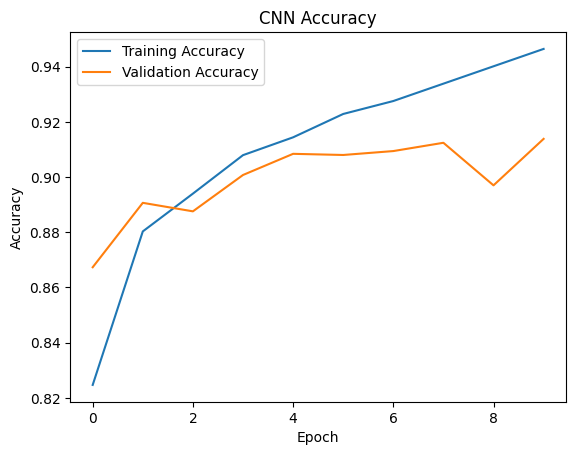

In [ ]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

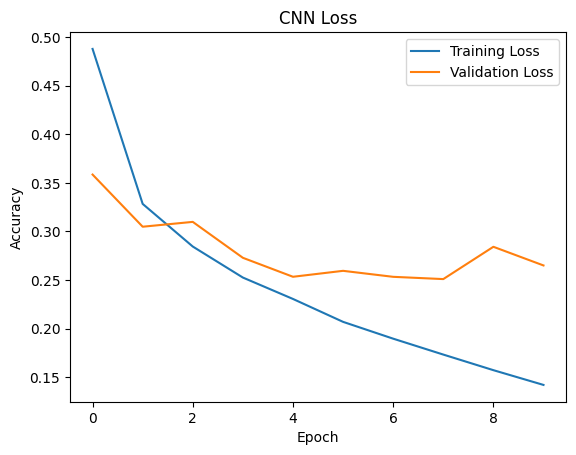

In [ ]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Loss')
plt.legend()
plt.show()

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print("Test Accuracy:",test_accuracy)
print("Test Loss:",test_loss)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 60000
'y' sizes: 10000


In [ ]:
predictions=model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
#Out of 10,000,check 1st one
print(predictions[0])

[2.1458749e-07 5.4476046e-10 6.4155631e-07 5.0539256e-07 1.0090096e-06
 2.8529719e-05 7.7897489e-08 1.9191753e-02 1.1213629e-06 9.8077619e-01]


In [ ]:
#Maximum probability class select cheyyum
predicted_class=np.argmax(predictions[0])
print("predicted class number:",predicted_class)
print("Predicted class:",class_names[predicted_class])

predicted class number: 9
Predicted class: Ankle boot


In [ ]:
print("Actual class:",class_names[y_test[0]])

Actual class: Ankle boot


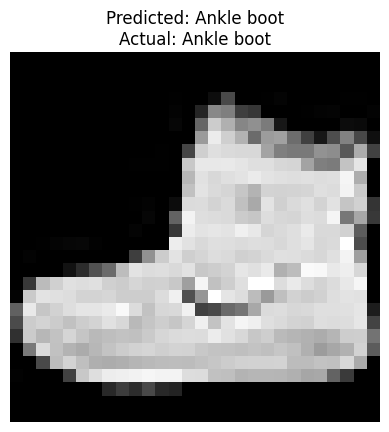

In [ ]:
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')

plt.title(
    "Predicted: " + class_names[predicted_class]
    + "\nActual: " + class_names[y_test[0]]
)

plt.axis('off')
plt.show()

In [ ]:
predictions = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


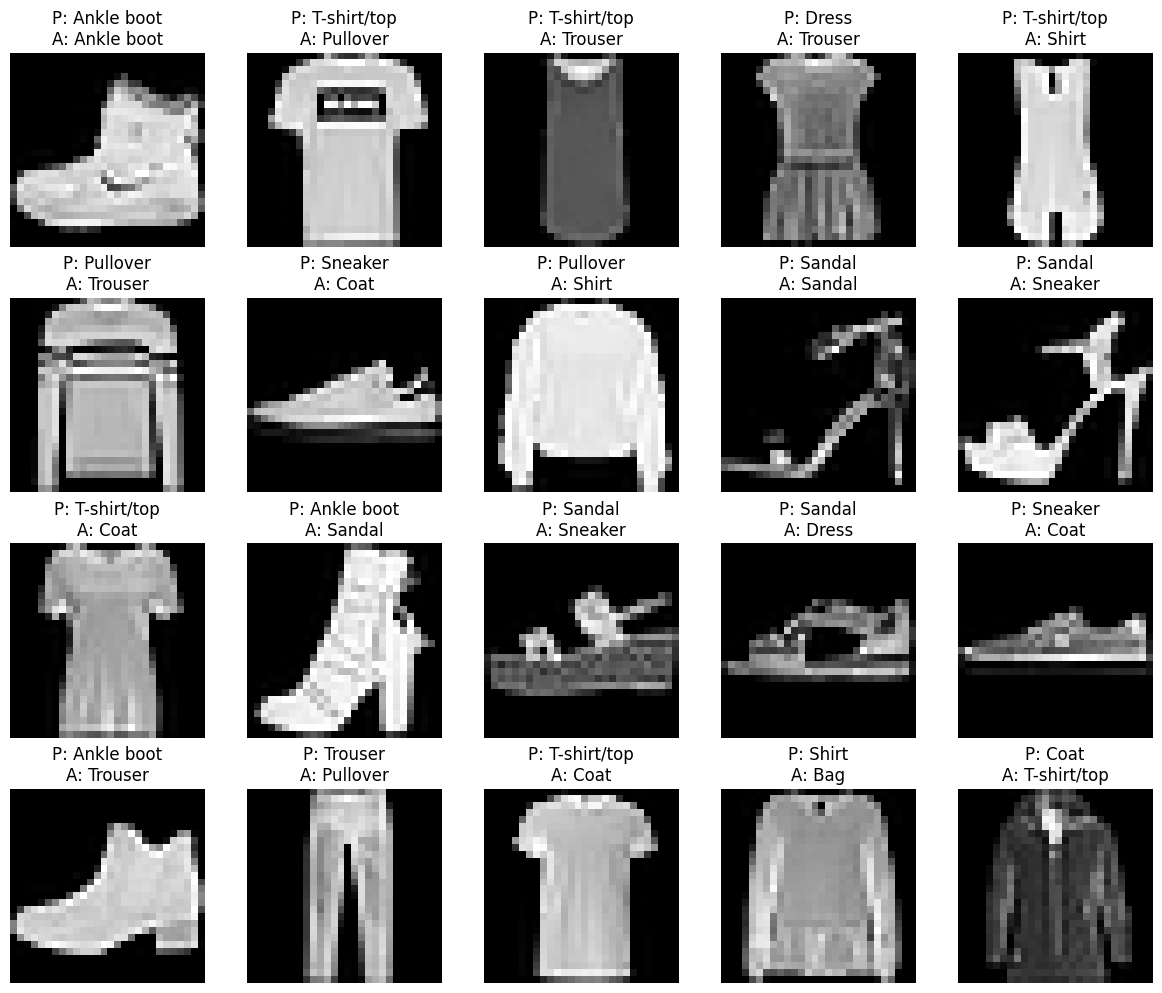

In [ ]:
predicted_labels=np.argmax(predictions,axis=1)#axis=1 Find maximum in the row
plt.figure(figsize=(12,10))
for i in range(20):
  plt.subplot(4,5,i+1)
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(
      "P: " + class_names[predicted_labels[i]]+
      "\nA: " + class_names[y_test[i]]
  )
  plt.axis('off')
plt.tight_layout()#To prevent overlapping of images
plt.show()

In [ ]:
print("y_test:", len(y_test))
print("predicted_labels:", len(predicted_labels))

y_test: 10000
predicted_labels: 60000


In [ ]:
print(predicted_labels.shape)

(60000,)


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [10000, 60000]

How to import dataset from kaggle

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rpranav2507","key":"e77a305b333277e9eb022dacb17f6589"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:19<00:00, 18.7MB/s]



In [ ]:
!ls

intel-image-classification.zip	kaggle.json  sample_data


In [ ]:
!mkdir -p intel_dataset

!unzip intel-image-classification.zip -d intel_dataset

Streaming output truncated to the last 5000 lines.
  inflating: intel_dataset/seg_train/seg_train/mountain/7506.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7537.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7539.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7551.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7560.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7565.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7578.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7581.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7586.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7647.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7652.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7654.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/7662.jpg  
  inflating: intel_dataset/seg_train/seg_train/mountain/767.jpg  
  inflating:

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers,models

In [ ]:
!find intel_dataset -maxdepth 2 -type d

intel_dataset
intel_dataset/seg_pred
intel_dataset/seg_pred/seg_pred
intel_dataset/seg_test
intel_dataset/seg_test/seg_test
intel_dataset/seg_train
intel_dataset/seg_train/seg_train


In [ ]:
train_dir="/content/intel_dataset/seg_train/seg_train"
test_dir="/content/intel_dataset/seg_test/seg_test"
pred_dir="/content/intel_dataset/seg_pred/seg_pred"

In [ ]:
print("Training folder:", train_dir)
print("Testing folder:", test_dir)
print("\nTraining Classes:")
print(os.listdir(train_dir))

Training folder: /content/intel_dataset/seg_train/seg_train
Testing folder: /content/intel_dataset/seg_test/seg_test

Training Classes:
['forest', 'mountain', 'street', 'glacier', 'sea', 'buildings']


In [ ]:
from genericpath import isdir
for class_name in os.listdir(train_dir):
  class_path=os.path.join(train_dir,class_name)
  if os.path.isdir(class_path):
    print(class_name,":",len(os.listdir(class_path)))

forest : 2271
mountain : 2512
street : 2382
glacier : 2404
sea : 2274
buildings : 2191


In [ ]:
IMG_SIZE=150
BATCH_SIZE=32

train_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42
)


Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [ ]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [ ]:
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [ ]:
class_names=train_ds.class_names
print(class_names)
print("Number of classes:",len(class_names))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [ ]:
for images,labels in train_ds.take(1):
  print("Image batch shape:", images.shape)
  print("Label batch shape:", labels.shape)
  print("Labels :",labels[:10].numpy())

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)
Labels : [1 5 5 1 1 3 0 4 1 2]


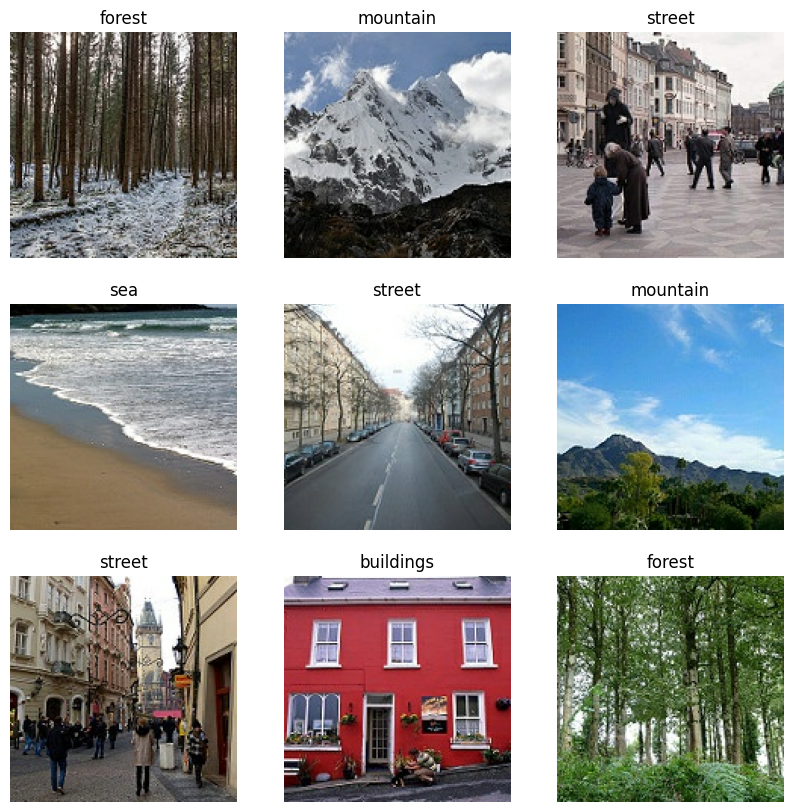

In [ ]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [ ]:
normalization_layer=layers.Rescaling(1./255)

In [ ]:
for images,labels in train_ds.take(1):
  normalized_images=normalization_layer(images)

  print("Before normalization")
  print("Minimum:",tf.reduce_min(images).numpy())
  print("Maximum:",tf.reduce_max(images).numpy())

  print("\nAfter normalization")
  print("Minimum:",tf.reduce_min(normalized_images).numpy())
  print("Maximum:",tf.reduce_max(normalized_images).numpy())

Before normalization
Minimum: 0.0
Maximum: 255.0

After normalization
Minimum: 0.0
Maximum: 1.0


In [ ]:
AUTOTUNE=tf.data.AUTOTUNE

train_ds=train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds=test_ds.prefetch(buffer_size=AUTOTUNE

In [ ]:
model=models.Sequential([
    layers.Input(shape=(150,150,3)),
    layers.Rescaling(1./255),

    #Covolution Block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv1"
    ),


    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool1"
    ),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        name="conv2"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool2"
    ),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        name="conv3"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool3"
    ),

    layers.Flatten(),

    #Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),
    #Output Layer
    layers.Dense(
        6,
        activation="softmax"
    )
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6303 - loss: 0.9567 - val_accuracy: 0.6985 - val_loss: 0.8074
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7656 - loss: 0.6321 - val_accuracy: 0.7773 - val_loss: 0.6110
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8362 - loss: 0.4572 - val_accuracy: 0.7798 - val_loss: 0.6625
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8905 - loss: 0.3070 - val_accuracy: 0.7976 - val_loss: 0.6648
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9273 - loss: 0.2096 - val_accuracy: 0.7979 - val_loss: 0.7491
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9537 - loss: 0.1349 - val_accuracy: 0.7908 - val_loss: 0.9313
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9646 - loss: 0.1090 - val_accuracy: 0.7523 - val_loss: 1.3358
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9727 - loss: 0.0801 - val

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
print(history.history["accuracy"])

[0.6302992701530457, 0.7655860185623169, 0.8362130522727966, 0.8904524445533752, 0.9273245334625244, 0.9536871910095215, 0.9645528793334961, 0.972746729850769, 0.9813858270645142, 0.9752404689788818]


In [ ]:
#Classification Report
from sklearn.metrics import classification_report
